In [63]:
import os
import sys
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

sys.path.insert(0, os.path.abspath("../../src"))
from pipeline import run_etl, DOMINIOS
from modeling import seed, scoring, get_confusion_matrix, cv_repeated_kfold, cv_kfold, graficar_curvas_roc_multiclase, print_scores,nested_cross_validation_multi
df_tabla_0_imp, df_tabla_1_imp, df_mean, df_median = run_etl("../../.env")

Descargando datos desde GitHub...
Hojas cargadas: 125
Tabla 0 (escolaridad baja) : 36
Tabla 1 (escolaridad alta) : 81
No determinadas            : 8
df_tabla_0 crudo : (36, 32)
df_tabla_1 crudo : (81, 29)

 Imputando nulos...
--- Perfil nulos Tabla 0 ---
                                         nulos  %_nulos dtype  n_unicos
fluidez_verbal_semantica                    23    63.89   str         4
matrices                                    12    33.33   str         4
imagenes_sobrepuestas                       11    30.56   str         3
stroop_interferencia                         9    25.00   str         4
material_verbal_complejo                     6    16.67   str         3
denominacion                                 5    13.89   str         1
stroop_palabra                               4    11.11   str         4
stroop_color                                 4    11.11   str         4
atencion_sostenida_visual                    4    11.11   str         4
evocacion_diferida       

In [ ]:
#tight_layout = True


In [2]:
#Features para el modelo
DOMINIOS_COGNITIVOS = list(DOMINIOS.keys())
features = [col for col in df_mean.columns if col != "dc"]

X_mean = df_mean[features]
y_mean = pd.to_numeric(df_mean["dc"], errors='coerce').fillna(-1).astype(int)

X_median = df_median[features]
y_median = pd.to_numeric(df_median["dc"], errors='coerce').fillna(-1).astype(int)

In [3]:
#Cargar modelos
model_package_lr = joblib.load('../../models/modelo_logistic_regression_diagnostico.joblib')
model_package_rf = joblib.load('../../models/modelo_random_forest_diagnostico.joblib')
model_package_svm_lineal = joblib.load('../../models/modelo_svm_lineal_diagnostico.joblib')
model_package_svm_rbf = joblib.load('../../models/modelo_svm_rbf_diagnostico.joblib')

In [4]:
models = {
    'Logistic Regression': model_package_lr,
    'Random Forest': model_package_rf,
    'SVM Lineal': model_package_svm_lineal,
    'SVM RBF': model_package_svm_rbf
}

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline


def permutation_importance_cv(
    model,
    X,
    y,
    cv,
    scoring='f1_macro',
    n_repeats=30,
    random_state=seed,
    model_name=None
):
    """
    Calcula la importancia por permutación sobre cada partición
    de validación cruzada y genera una gráfica con el nombre del modelo en el título.
    """

#Model name
    if model_name is None:
        if isinstance(model, Pipeline):
            # Si es un Pipeline, toma el nombre de la clase del último estimador
            model_name = type(model.steps[-1][1]).__name__
        else:
            # Si es un modelo directo, toma su nombre de clase
            model_name = type(model).__name__

    importancias_folds = []

    #Validación cruzada
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):

        # Separación entre entrenamiento y validación
        X_train = X.iloc[train_idx] if hasattr(X, 'iloc') else X[train_idx]
        X_val = X.iloc[val_idx] if hasattr(X, 'iloc') else X[val_idx]

        y_train = y.iloc[train_idx] if hasattr(y, 'iloc') else y[train_idx]
        y_val = y.iloc[val_idx] if hasattr(y, 'iloc') else y[val_idx]

        # copia del modelo para no reescribirlo
        modelo_fold = clone(model)

        # se entrena unicamente con los datos de entrenamiento
        modelo_fold.fit(X_train, y_train)

        # Caculo del permutation importance
        resultado = permutation_importance(
            modelo_fold,
            X_val,
            y_val,
            scoring=scoring,
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1
        )

        importancias_folds.append(resultado.importances_mean)

    # matriz de importancias por fold
    importancias_folds = np.array(importancias_folds)

    # Promedio y Desviación Estándar
    importancia_media = np.mean(importancias_folds, axis=0)
    importancia_std = np.std(importancias_folds, axis=0)

    # dataset final
    nombres_variables = [col.replace('_', ' ').capitalize() for col in X.columns]
    
    df_importancia = pd.DataFrame({
        'Variable': nombres_variables,
        'Importancia_Media': importancia_media,
        'Importancia_Std': importancia_std
    }).sort_values(by='Importancia_Media', ascending=False).reset_index(drop=True)

    #Gráficar

    altura_fig = max(6, len(df_importancia) * 0.4)
    fig, ax = plt.subplots(figsize=(10, altura_fig))

    posiciones = np.arange(len(df_importancia))

    norm = plt.Normalize(
        df_importancia['Importancia_Media'].min(),
        df_importancia['Importancia_Media'].max()
    )

    colores = plt.cm.viridis(norm(df_importancia['Importancia_Media']))

    ax.barh(
        posiciones,
        df_importancia['Importancia_Media'],
        xerr=df_importancia['Importancia_Std'],
        capsize=4,
        color=colores,
        ecolor='black',
        alpha=0.85
    )

    ax.set_yticks(posiciones)
    ax.set_yticklabels(df_importancia['Variable'], fontsize=10)

    # Ordenar por importancia media
    ax.invert_yaxis()

    # Etiquetas de los ejes
    metric_label = scoring.replace('_', ' ').upper() if isinstance(scoring, str) else 'Métrica'
    ax.set_xlabel(f'Disminución promedio en {metric_label}', fontsize=11, labelpad=10)
    ax.set_ylabel('Variable', fontsize=11)
    
    ax.set_title(f'Importancia de las variables ({model_name})', fontweight='bold', fontsize=13)

    # Línea vertical de referencia en 0
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    
    max_reach = (df_importancia['Importancia_Media'] + df_importancia['Importancia_Std']).max()
    min_reach = (df_importancia['Importancia_Media'] - df_importancia['Importancia_Std']).min()

    rango = max_reach - min(0, min_reach)
    offset = rango * 0.02 if rango > 0 else 0.005

    for i, (valor, desviacion) in enumerate(zip(df_importancia['Importancia_Media'], df_importancia['Importancia_Std'])):
        if valor >= 0:
            pos_x = valor + desviacion + offset
            ha_align = 'left'
        else:
            pos_x = valor - desviacion - offset
            ha_align = 'right'

        ax.text(
            pos_x,
            i,
            f'{valor:.4f} ± {desviacion:.4f}',
            va='center',
            ha=ha_align,
            fontsize=8.5,
            fontweight='bold'
        )

    lim_max = max_reach + (rango * 0.25) if max_reach > 0 else 0.05
    lim_min = min_reach - (rango * 0.25) if min_reach < 0 else -0.01
    
    ax.set_xlim(lim_min, lim_max)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    return df_importancia, fig

In [92]:
from sklearn.model_selection import RepeatedStratifiedKFold

cv_externo = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=seed
)

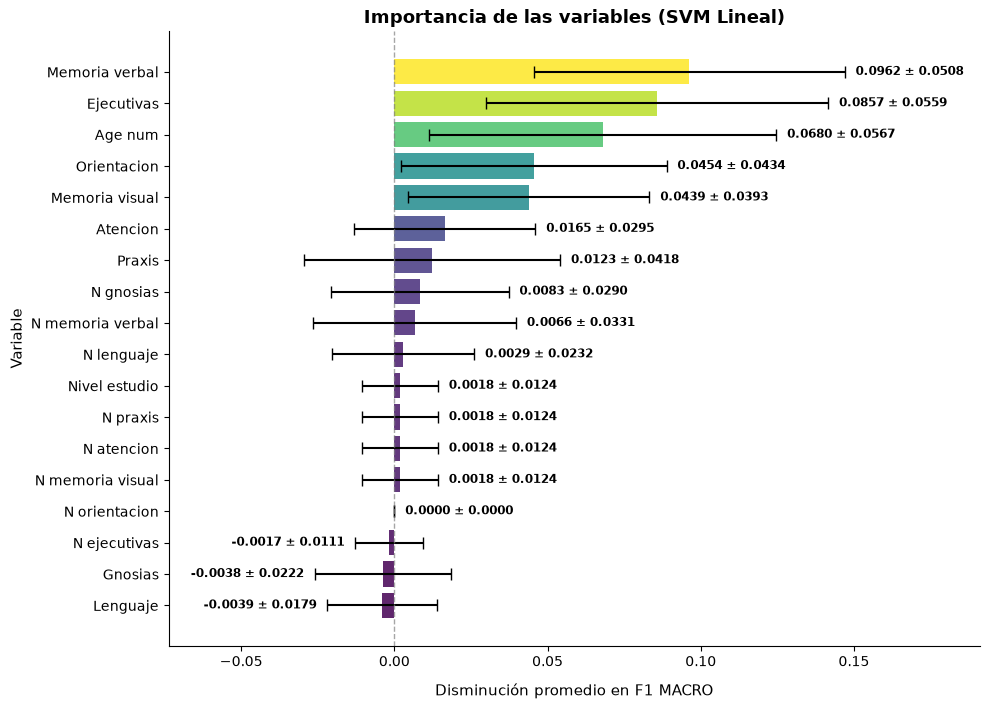

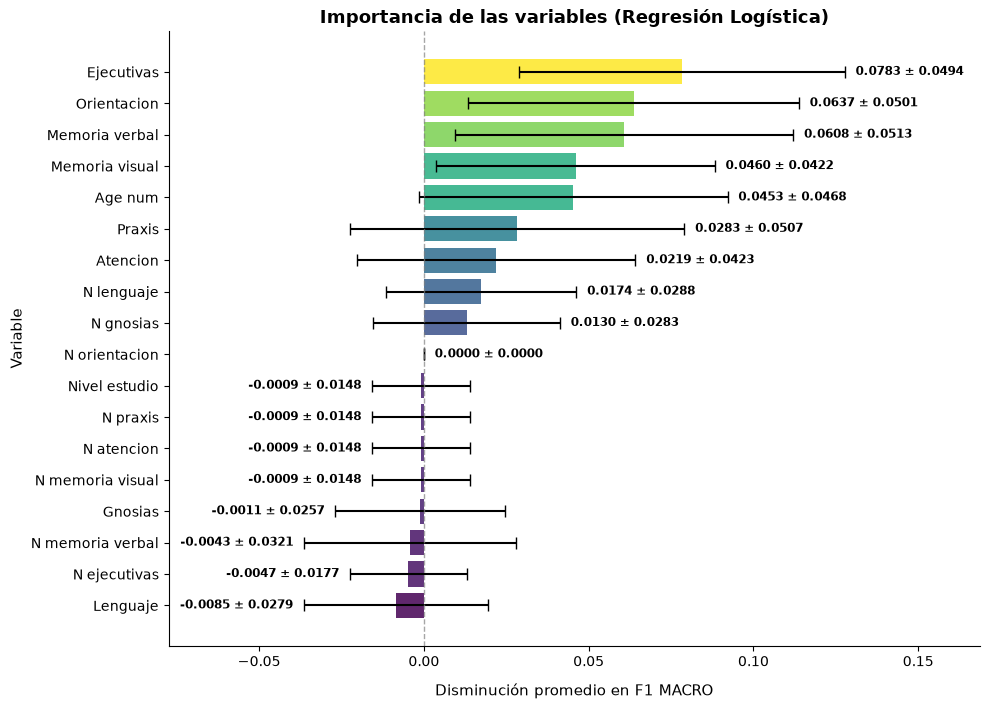

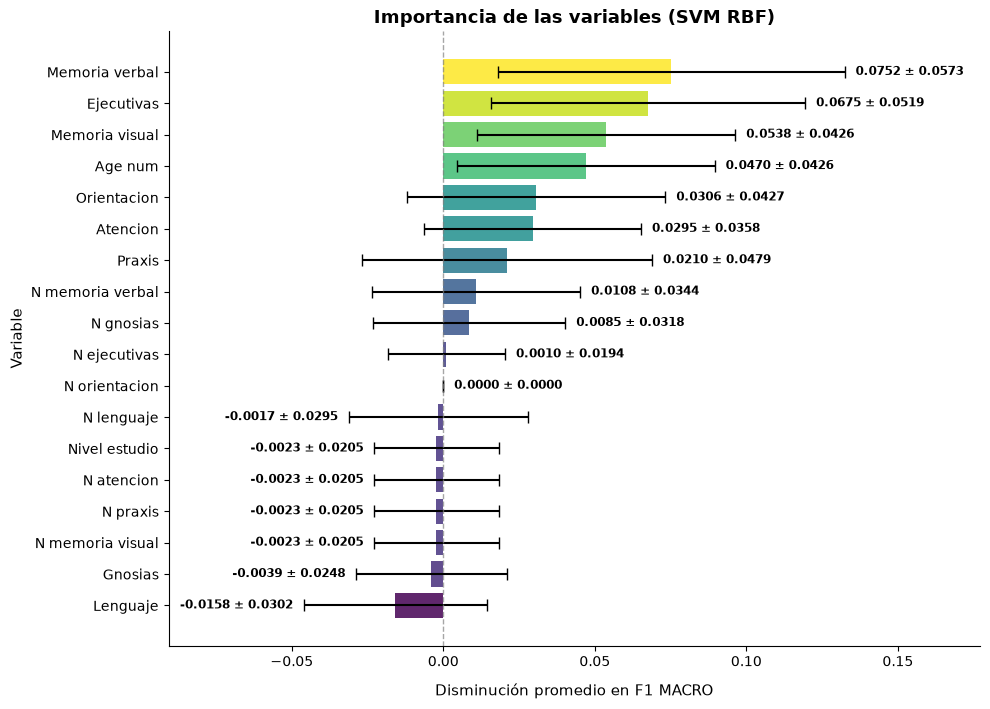

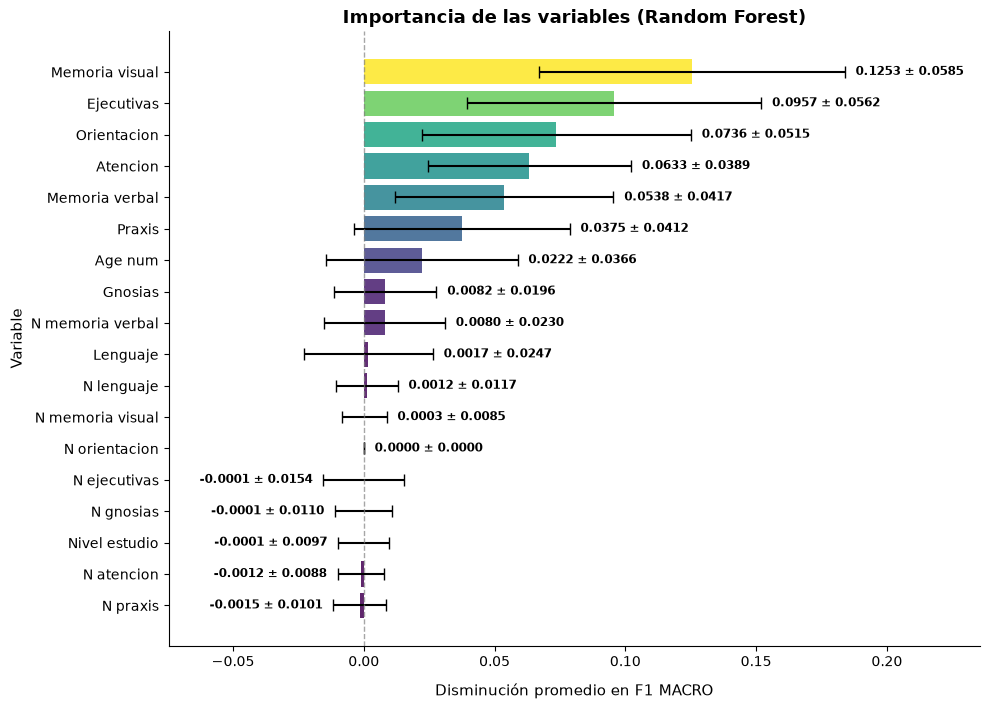

(            Variable  Importancia_Media  Importancia_Std
 0     Memoria visual           0.125344         0.058545
 1         Ejecutivas           0.095748         0.056216
 2        Orientacion           0.073578         0.051495
 3           Atencion           0.063335         0.038867
 4     Memoria verbal           0.053767         0.041676
 5             Praxis           0.037549         0.041153
 6            Age num           0.022170         0.036605
 7            Gnosias           0.008179         0.019605
 8   N memoria verbal           0.007979         0.023049
 9           Lenguaje           0.001728         0.024669
 10        N lenguaje           0.001193         0.011747
 11  N memoria visual           0.000261         0.008454
 12     N orientacion           0.000000         0.000000
 13      N ejecutivas          -0.000071         0.015365
 14         N gnosias          -0.000085         0.010969
 15     Nivel estudio          -0.000112         0.009727
 16        N a

In [102]:
permutation_importance_cv(
    model=models['SVM Lineal'],
    X=X_mean,
    y=y_mean,
    cv=cv_externo,
    scoring='f1_macro',
    n_repeats=30,
    random_state=seed,
    model_name='SVM Lineal' 
)
permutation_importance_cv(
    model=models['Logistic Regression'],
    X=X_mean,
    y=y_mean,
    cv=cv_externo,
    scoring='f1_macro',
    n_repeats=30,
    random_state=seed,
    model_name= 'Regresión Logística'
)
permutation_importance_cv(
    model=models['SVM RBF'],
    X=X_mean,
    y=y_mean,
    cv=cv_externo,
    scoring='f1_macro',
    n_repeats=30,
    random_state=seed,
    model_name='SVM RBF'
)
permutation_importance_cv(
    model=models['Random Forest'],
    X=X_mean,
    y=y_mean,
    cv=cv_externo,
    scoring='f1_macro',
    n_repeats=30,
    random_state=seed,
    model_name='Random Forest'
)

In [ ]:
# # Predicción con un paciente de ejemplo (fila 5 del dataset)
# paciente_ejemplo = X_mean.iloc[[5]]

# # Usamos predict_proba en lugar de predict
# probabilidades = rf_pipeline.predict_proba(paciente_ejemplo)[0]

# print(f"Probabilidad de ser Control Sano {probabilidades[0]*100:.1f}%")
# print(f"Probabilidad de tener DCL {probabilidades[1]*100:.1f}%")
# print(f"Probabilidad de tener Demencia {probabilidades[2]*100:.1f}%")


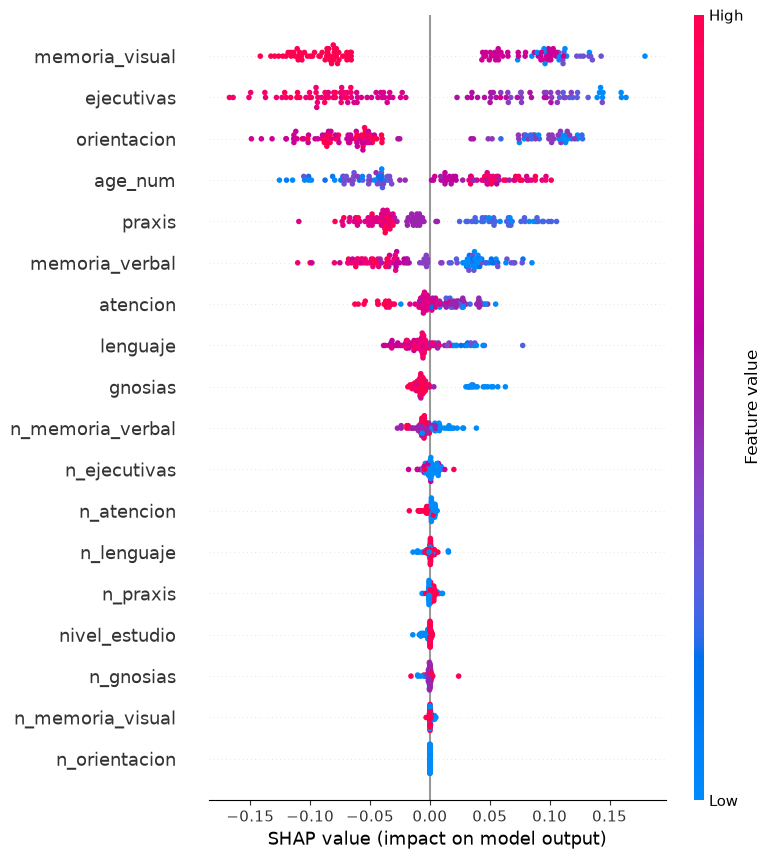

In [ ]:
#Shap con javascript
import shap

shap.initjs()

# Random forest entrenado y datos limpios
rf_model = rf_pipeline.steps[-1][1]
imputer = rf_pipeline.steps[0][1]
X_limpio = imputer.transform(X_mean)

# Se crea el objeto explainer de SHAP para el modelo Random Forest entrenado y los datos limpios
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_limpio)

#Solución al error de dimensiones en SHAP
# Verificación de cómo estructuró SHAP los datos (Lista vs Matriz 3D)
if isinstance(shap_values, list):
    # Versión antigua. Lista. El índice 2 corresponde a la clase 'Demencia'
    shap_demencia = shap_values[2]
else:
    # Nueva versión. cubo 3D [pacientes, variables, clases]
    # Se corta el cubo para extraer solo la rebanada de la clase 2 ('Demencia')
    shap_demencia = shap_values[:, :, 2]

# Se gráfica el resumen de SHAP para la clase 'Demencia', mostrando el impacto de cada variable en la predicción del modelo.
shap.summary_plot(shap_demencia, X_limpio, feature_names=X_mean.columns, title="Impacto de Variables para diagnosticar Demencia")
